## Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs. Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

In [1]:
# If you didn't download it yet, please get the relevant file now!
!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/data/

"wget" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

2\. Find out the number of BX in a ORBIT (the value 'x').

3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

6\. Create a new DataFrame that contains only the rows with HEAD=1.

7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

8\. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Pandas DataFrame reading N rows of the 'data_000637.txt' dataset.
file_name = "/Users/itter/UNIPD 1st year programming/LaboratoryOfComputationalPhysics_Y8/data/data_000637.txt"
df = pd.read_csv(file_name)

def load_data(N):
    if 10000 < N <= (len(df)):
        return df.iloc[:N]
    else:
        return print(f"N must be > 10000 and ≤ {len(df)}")

In [4]:
load_data(1310720)

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS
0,1,0,123,3869200167,2374,26
1,1,0,124,3869200167,2374,27
2,1,0,63,3869200167,2553,28
3,1,0,64,3869200167,2558,19
4,1,0,64,3869200167,2760,25
...,...,...,...,...,...,...
1310715,1,0,62,3869211171,762,14
1310716,1,1,4,3869211171,763,11
1310717,1,0,64,3869211171,764,0
1310718,1,0,139,3869211171,769,0


In [5]:
# Number of BX in a ORBIT (the value 'x'). Is the highest number before "BX_COUNTER" resets to 0.
BX_PER_ORBIT = df.groupby("ORBIT_CNT")["BX_COUNTER"].max()
print(BX_PER_ORBIT,'\n')
x = BX_PER_ORBIT.max() + 1 # As in the +1 it resets to 0.
print(f'The number of BX in a ORBIT is',x) 

ORBIT_CNT
3869200167    3187
3869200168    3538
3869200169    2766
3869200170    3377
3869200171    3542
              ... 
3869211167    3553
3869211168    3556
3869211169    3498
3869211170    3527
3869211171     769
Name: BX_COUNTER, Length: 11001, dtype: int64 

The number of BX in a ORBIT is 3564


In [6]:
# How much the data taking lasted.
BX_TIME = 25e-9         
TDC_TIME = 25e-9 / 30  

# Method to calculate the time explicitly, by computing the completed orbits and then adding the last and the first.
ORBITS = df["ORBIT_CNT"].max() - df["ORBIT_CNT"].min()
Time = ( (ORBITS - 2) * x + BX_PER_ORBIT.iloc[len(BX_PER_ORBIT)-1] + BX_PER_ORBIT.iloc[0] - df["BX_COUNTER"].iloc[0] ) * BX_TIME
print(f'First method:',Time,'\n')

# Method to change units to seconds and then subtract the initial time from the final time.
df["time_s"] = (
    df["ORBIT_CNT"] * x * BX_TIME
    + df["BX_COUNTER"] * BX_TIME
    + df["TDC_MEAS"] * TDC_TIME
)
data_taking_time = df["time_s"].max() - df["time_s"].min()
print(f'Second method (better):',data_taking_time,'\n')

First method: 0.98031775 

Second method (better): 0.9804162533255294 



In [7]:
# New column with the absolute time in ns.
df["time_ns"] = df["time_s"] * 1e9
df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,time_s,time_ns
0,1,0,123,3869200167,2374,26,344745.734939,3.447457e+14
1,1,0,124,3869200167,2374,27,344745.734939,3.447457e+14
2,1,0,63,3869200167,2553,28,344745.734944,3.447457e+14
3,1,0,64,3869200167,2558,19,344745.734944,3.447457e+14
4,1,0,64,3869200167,2760,25,344745.734949,3.447457e+14
...,...,...,...,...,...,...,...,...
1310715,1,0,62,3869211171,762,14,344746.715355,3.447467e+14
1310716,1,1,4,3869211171,763,11,344746.715355,3.447467e+14
1310717,1,0,64,3869211171,764,0,344746.715355,3.447467e+14
1310718,1,0,139,3869211171,769,0,344746.715355,3.447467e+14


In [8]:
# Replace the values (all 1) of the HEAD column randomly with 0 or 1.
df["HEAD"] = np.random.choice([0, 1], size=len(df)) # We can include more numbers or even probabilities as a 3rd input "p=[prob1, prob2]".
df

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,time_s,time_ns
0,1,0,123,3869200167,2374,26,344745.734939,3.447457e+14
1,1,0,124,3869200167,2374,27,344745.734939,3.447457e+14
2,0,0,63,3869200167,2553,28,344745.734944,3.447457e+14
3,1,0,64,3869200167,2558,19,344745.734944,3.447457e+14
4,0,0,64,3869200167,2760,25,344745.734949,3.447457e+14
...,...,...,...,...,...,...,...,...
1310715,0,0,62,3869211171,762,14,344746.715355,3.447467e+14
1310716,1,1,4,3869211171,763,11,344746.715355,3.447467e+14
1310717,1,0,64,3869211171,764,0,344746.715355,3.447467e+14
1310718,0,0,139,3869211171,769,0,344746.715355,3.447467e+14


In [9]:
# New DataFrame that contains only the rows with HEAD=1.
df2 = df[ df["HEAD"] == 1 ]
df2

,HEAD,FPGA,TDC_CHANNEL,ORBIT_CNT,BX_COUNTER,TDC_MEAS,time_s,time_ns
0,1,0,123,3869200167,2374,26,344745.734939,3.447457e+14
1,1,0,124,3869200167,2374,27,344745.734939,3.447457e+14
3,1,0,64,3869200167,2558,19,344745.734944,3.447457e+14
5,1,0,63,3869200167,2762,4,344745.734949,3.447457e+14
6,1,0,61,3869200167,2772,14,344745.734949,3.447457e+14
...,...,...,...,...,...,...,...,...
1310713,1,0,64,3869211171,758,18,344746.715355,3.447467e+14
1310714,1,0,60,3869211171,762,2,344746.715355,3.447467e+14
1310716,1,1,4,3869211171,763,11,344746.715355,3.447467e+14
1310717,1,0,64,3869211171,764,0,344746.715355,3.447467e+14


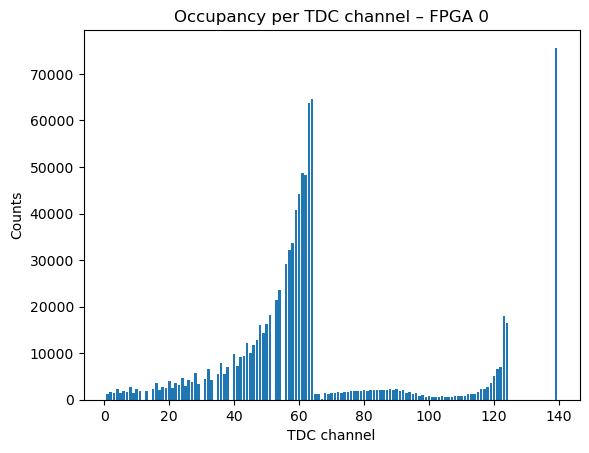

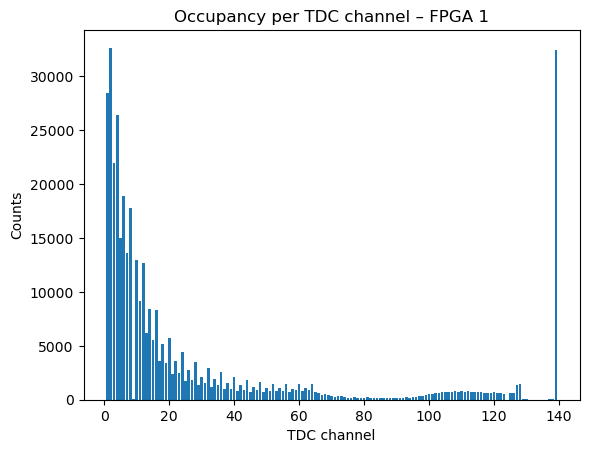

In [10]:
# Two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel.
FPGA0 = df[ df["FPGA"] == 0 ]
FPGA1 = df[ df["FPGA"] == 1 ]
occ_fpga0 = FPGA0["TDC_CHANNEL"].value_counts() # We could use ".sort_index()" to set in order the channels.
occ_fpga1 = FPGA1["TDC_CHANNEL"].value_counts()

plt.figure()
plt.bar(occ_fpga0.index, occ_fpga0.values)
plt.xlabel("TDC channel")
plt.ylabel("Counts")
plt.title("Occupancy per TDC channel – FPGA 0")
plt.show()

plt.figure()
plt.bar(occ_fpga1.index, occ_fpga1.values)
plt.xlabel("TDC channel")
plt.ylabel("Counts")
plt.title("Occupancy per TDC channel – FPGA 1")
plt.show()

In [11]:
# Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3).
noise = df.groupby("TDC_CHANNEL").size().nlargest(3) # "size()" # size() gives the number of events per TDC channel.
print("Noisy channels:", noise.index.tolist()) # We need to convert indeces to list for a clean output.

Noisy channels: [139, 64, 63]


In [12]:
# Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139.
n_orbits = df["ORBIT_CNT"].nunique()

df_139 = df[df["TDC_CHANNEL"] == 139]
n_orbits_139 = df_139["ORBIT_CNT"].nunique()
print(f'Then number of unique orbits is',n_orbits,f'and there are',n_orbits_139,f'form TDC_CHANNEL=139.')

Then number of unique orbits is 11001 and there are 10976 form TDC_CHANNEL=139.
